<a href="https://colab.research.google.com/github/ArelySoto/connectatel-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

In [ ]:


# mostrar las primeras 5 filas de users

users.head(5)


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset

print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

In [ ]:
# inspección de plans con .info()
plans.info()

In [ ]:
# inspección de users con .info()
users.info()

In [ ]:
# inspección de usage con .info()
usage.info()

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean()*100)


In [ ]:

# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean()*100)


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:

 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
city	11.73%
churn_date	88.35%
date	0.125%
duration	55.19%
length	44.74%
- Indica qué harías: ¿imputar, eliminar, ignorar?
- city (11.73%) → Imputar o mantener como categoría "Desconocida".
Porque tiene una proporción moderada de nulos y la variable puede ser útil para segmentar usuarios.
churn_date (88.35%) → Ignorar.
Porque los nulos indican que el cliente no ha cancelado el servicio, por lo que tienen significado de negocio.
date (0.125%) → Eliminar o imputar.
Porque la cantidad de registros afectados es mínima y no impactará significativamente el análisis.
duration (55.19%) → Ignorar.
Porque los nulos corresponden a registros de mensajes, donde no existe duración de llamada.
length (44.74%) → Ignorar.
Porque los nulos corresponden a registros de llamadas, donde no existe longitud de mensaje.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:

# explorar columnas numéricas de users
users.describe()



- La columna `user_id`No se observan anomalías evidentes en user_id.
- No parece tener valores raros o fuera de rango.
Los valores van de 10000 a 13999, lo cual coincide con 4,000 usuarios únicos.
Además, al ser un identificador, no se espera una distribución específica, solo que los valores sean únicos.
- La columna `age` El valor -999 es una anomalía y debe investigarse. Lo recomendable sería reemplazarlo por NaN y posteriormente imputarlo o tratarlo como dato faltante.
- El valor mínimo es -999, lo cual no tiene sentido para una edad real.
Las edades humanas no pueden ser negativas, por lo que este valor probablemente representa un dato erróneo o un código utilizado para indicar un valor faltante.
El resto de los percentiles (32, 47, 63) y el máximo (79) parecen razonables.
  

In [ ]:
# explorar columnas numéricas de usage
usage.describe()


En general, los valores de duration son razonables, aunque conviene investigar los registros con duración igual a 0.
La mayoría de las llamadas duran entre 1.44 y 6.99 minutos, con una mediana de 3.5 minutos, lo cual parece razonable.
El valor máximo de 120 minutos (2 horas) es alto, pero todavía posible para una llamada telefónica.
El valor mínimo de 0 minutos llama la atención, ya que podría representar llamadas perdidas, canceladas o errores de registro.
Los valores de length parecen razonables en general, pero los valores de 0 caracteres y el máximo de 1490 caracteres merecen una revisión adicional para confirmar que sean válidos.
El valor máximo de 1490 caracteres es bastante alto para un SMS tradicional, pero podría corresponder a mensajes largos o concatenados.
El valor mínimo de 0 caracteres resulta sospechoso, ya que indicaría mensajes vacíos o errores de captura.



In [ ]:
columnas_user = ['city','plan']

for col in columnas_user:
    print(f'\n{col}')
    print(users[col].value_counts(dropna=False))

La columna city contiene principalmente ciudades válidas, pero presenta 469 valores nulos (11.73%) y 96 registros con el valor "?", que probablemente representan datos faltantes o mal capturados. Conviene convertir "?" a NaN y posteriormente evaluar una estrategia de imputación o mantenerlos como desconocidos.
La columna plan no presenta valores faltantes visibles y contiene únicamente dos categorías válidas (Básico y Premium). La distribución parece consistente, por lo que no se observan problemas de calidad en esta variable.

In [ ]:
# explorar columna
usage['type'].value_counts(dropna=False)

- La columna `type` La columna type contiene únicamente dos categorías válidas: text (22,092 registros) y call (17,908 registros). No se observan valores faltantes ni categorías inesperadas, por lo que la variable parece consistente y no requiere limpieza adicional.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
age: contiene el valor -999, que no corresponde a una edad real y probablemente representa un dato faltante.
city: contiene el valor "?", que parece utilizarse como marcador de información desconocida o no registrada.
- ¿Qué acción tomarías?
- age (valor -999): reemplazar -999 por NaN, ya que no representa una edad válida y probablemente se utilizó como marcador de dato faltante. Posteriormente, evaluar si conviene imputar la edad o dejarla como valor faltante.
city (valor "?"): reemplazar "?" por NaN, ya que no corresponde a una ciudad válida. Después, se puede imputar la ciudad, asignar una categoría como "Desconocida" o mantener los nulos según las necesidades del análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(
    users['reg_date'],
    errors='coerce')


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(
    usage['date'],
    errors='coerce'
)

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

Valores fuera de rango en reg_date

Al analizar el año de registro, se observó que la mayoría de los registros corresponden a los años 2022, 2023 y 2024, que son consistentes con el período esperado de los datos. Sin embargo, existen 40 registros con fecha en 2026, un año que está fuera del rango válido.

Es probable que estos registros se deban a un error de captura de datos o a un problema en el sistema al registrar las fechas. Dado que representan solo el 1% de los usuarios (40 de 4,000), es recomendable investigarlos antes de continuar con el análisis.

Acción recomendada: revisar si es posible corregir las fechas utilizando información adicional. Si no existe una forma confiable de corregirlas, sería preferible eliminar esos registros para evitar sesgos o inconsistencias en el análisis.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

No se identificaron años fuera de rango en la columna date del dataset usage, ya que todos los registros con fecha válida corresponden al año 2024. Los 50 registros faltantes no aparecen en el conteo porque contienen valores nulos en la fecha (NaN), los cuales ya habían sido identificados previamente durante el análisis de valores faltantes.

✍️ **Comentario**:

Se analizaron las columnas reg_date del dataset users y date del dataset usage.

reg_date presenta 40 registros con el año 2026, que está fuera del rango esperado de los datos (2022–2024). Esto sugiere un posible error de captura o de sistema.
Acción recomendada: revisar si es posible corregir estas fechas utilizando información adicional; si no es posible validarlas, eliminar los registros o marcarlos como datos inválidos para evitar afectar el análisis.
date no presenta años fuera de rango, ya que todos los registros válidos corresponden a 2024. Sin embargo, existen 50 valores faltantes en esta columna.
Acción recomendada: investigar si las fechas pueden recuperarse; de lo contrario, eliminar esos pocos registros o mantenerlos como nulos, ya que representan una proporción muy pequeña del total.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Sí, se identificaron 40 registros con el año 2026 en la columna reg_date, un año que está fuera del período esperado de los datos (2022–2024). No se encontraron años imposibles o fuera de rango en la columna date del dataset usage; todos los registros válidos corresponden a 2024.
- ¿Qué harías con ellas?
- Investigar el origen de los registros con fecha en 2026 para determinar si se trata de un error de captura o de sistema. Si es posible validar y corregir las fechas, se deberían ajustar; de lo contrario, sería recomendable excluir esos registros del análisis para evitar inconsistencias en los resultados.


## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:


# Reemplazar -999 por la mediana de age

age_mediana = users.loc[
    users['age'] != -999,
    'age'
].median()

users['age'] = users['age'].replace(
    -999,
    age_mediana
)



In [ ]:
# ¿Todavía existen valores -999?
print((users['age'] == -999).sum())

0


In [ ]:
# Reemplazar ? por NA en city


users['city'] = users['city'].replace(
    '?',
    pd.NA
)


# Verificar cambios
users['city'].value_counts(dropna=False)



Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:

# Marcar fechas futuras como NA para reg_date
users.loc[
    users['reg_date'].dt.year > 2024,
    'reg_date'
] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts().sort_index()



2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:

# Verificación MAR en usage (Missing At Random) para duration
pd.crosstab(
    usage['type'],
    usage['duration'].isna(),
    normalize='index'
)*100



duration,False,True
type,,
call,100.000000,0.000000
text,0.072424,99.927576


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
pd.crosstab(
    usage['type'],
    usage['length'].isna(),
    normalize='index'
)*100

length,False,True
type,,
call,0.067009,99.932991
text,100.000000,0.000000


Los valores nulos en estas columnas no son aleatorios ni representan errores de captura. Al cruzar las variables con type, se observa que los registros de tipo call tienen prácticamente 0% de nulos en duration y cerca de 100% de nulos en length, mientras que los registros de tipo text presentan el comportamiento contrario: casi 100% de nulos en duration y 0% de nulos en length. Esto indica que los nulos son esperados debido a la naturaleza de cada tipo de registro. Por lo tanto, no se recomienda imputar ni eliminar estos valores, sino mantenerlos tal como están, ya que contienen información válida sobre el tipo de actividad registrada.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar información por usuario
usage_agg = (
    usage
    .groupby('user_id')
    .agg({
        'is_text':'sum',
        'is_call':'sum',
        'duration':'sum'
    })
    .reset_index()
)
# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = (
    usage
    .groupby('user_id')
    .agg({
        'is_text':'sum',
        'is_call':'sum',
        'duration':'sum'
    })
    .reset_index()
)
# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:


# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg = usage_agg.rename(
    columns={
        'is_text':'cant_mensajes',
        'is_call':'cant_llamadas',
        'duration':'cant_minutos_llamada'
    }
)
user_profile.head(5)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [ ]:
user_profile = user_profile.merge(
    users,
    on='user_id',
    how='left'
)

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[
    [
        'age',
        'cant_mensajes',
        'cant_llamadas',
        'cant_minutos_llamada'
    ]
].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(
    normalize=True
)*100

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

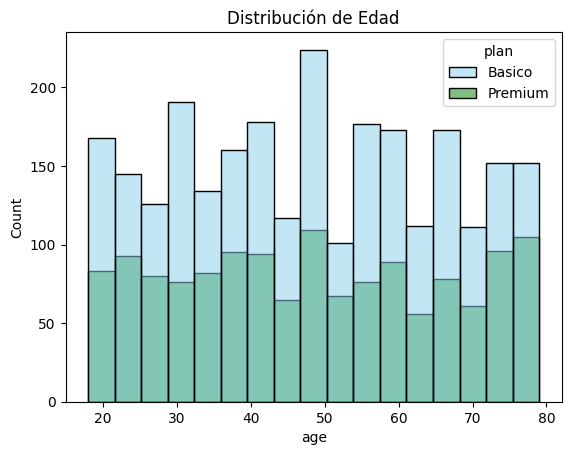

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue','green']
)

plt.title('Distribución de Edad')
plt.show()

💡Insights:
Las edades se encuentran distribuidas de manera relativamente uniforme entre los diferentes rangos.
No se observa una concentración fuerte en un grupo etario específico.
Los planes Básico y Premium están representados en prácticamente todas las edades.
La edad, a simple vista, no parece ser un factor determinante para la elección del plan

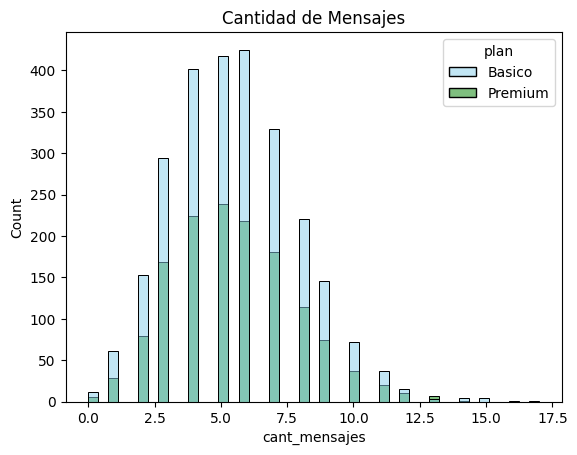

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue','green']
)

plt.title('Cantidad de Mensajes')
plt.show()

💡Insights:
- La distribución de mensajes es similar entre los planes Básico y Premium.
La mayoría de los usuarios envía una cantidad moderada de mensajes, concentrándose en valores intermedios.
No se observan diferencias marcadas entre planes, aunque el plan Básico tiene más usuarios en general.
Existen algunos usuarios con cantidades de mensajes inusualmente altas, pero son pocos casos.

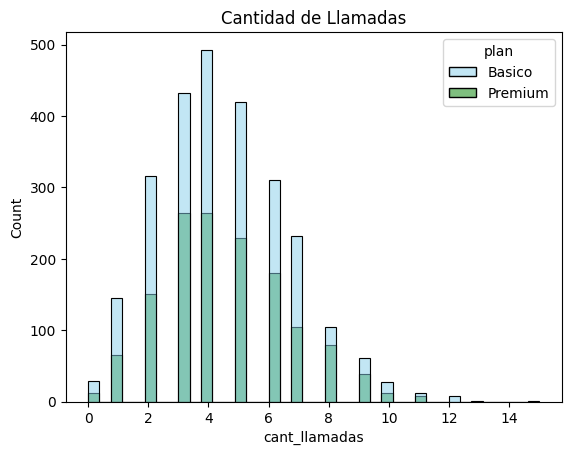

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue','green']
)

plt.title('Cantidad de Llamadas')
plt.show()

💡Insights:
La mayoría de los usuarios realiza entre 2 y 6 llamadas durante el período analizado.
Ambos planes presentan patrones de uso muy parecidos.
Se observan pocos usuarios con una cantidad elevada de llamadas, formando una cola hacia la derecha.
No parece haber una diferencia clara en el número de llamadas entre los planes.

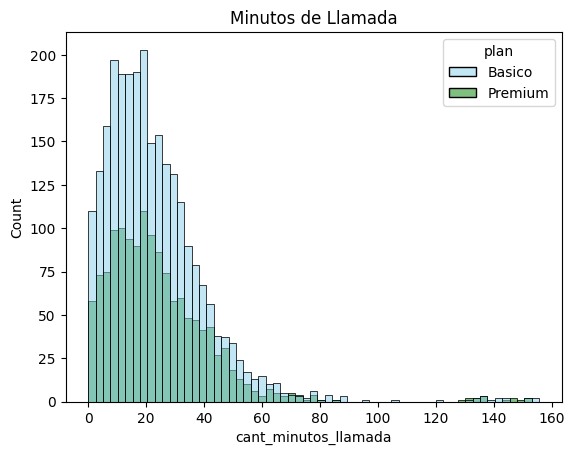

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue','green']
)

plt.title('Minutos de Llamada')
plt.show()

💡Insights:
-La distribución está sesgada a la derecha: la mayoría de los usuarios consume pocos minutos y unos pocos consumen muchos.
Se observan valores extremos superiores a 120 minutos.
Los usuarios Premium parecen tener una mayor presencia en los niveles más altos de consumo.
Esto podría indicar que algunos clientes Premium utilizan más intensivamente el servicio de llamadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

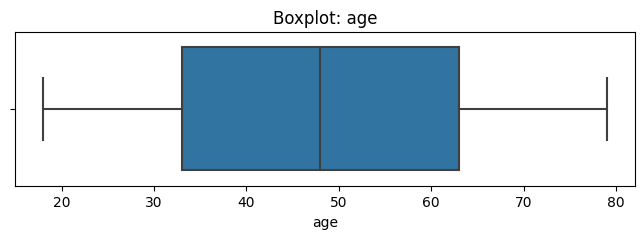

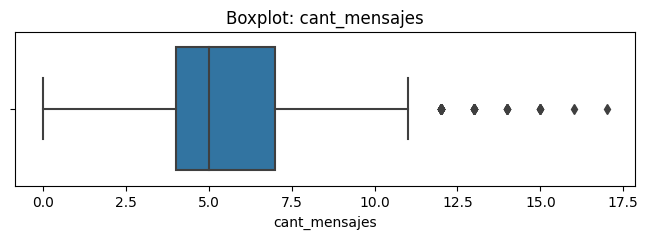

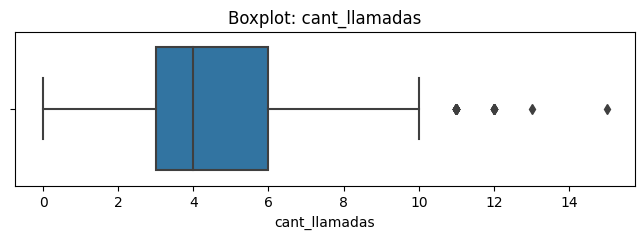

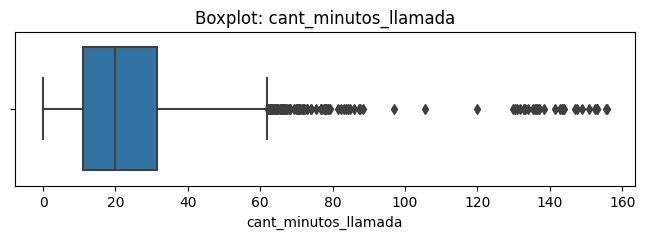

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=user_profile[col]
    )

    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:

Age: No se observan valores atípicos después de la limpieza de datos. La distribución de edades se encuentra dentro de rangos razonables para los usuarios del servicio.
cant_mensajes: Se identifican algunos valores atípicos en la parte superior de la distribución (usuarios que envían muchos más mensajes que la mayoría). Se recomienda mantenerlos, ya que pueden representar usuarios con un uso intensivo real del servicio y aportan información valiosa sobre el comportamiento de los clientes.
cant_llamadas: Existen algunos valores atípicos con un número elevado de llamadas. Se recomienda conservarlos, porque son plausibles dentro del contexto del negocio y podrían corresponder a usuarios con un patrón de uso más frecuente.
cant_minutos_llamada: Es la variable con mayor cantidad de valores atípicos. La distribución presenta una cola larga hacia la derecha, indicando que algunos usuarios consumen muchos más minutos que el promedio. Se recomienda mantener estos valores, ya que reflejan diferencias reales en el uso del servicio y son relevantes para analizar el comportamiento de los clientes y la posible elección de plan.


In [ ]:
# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:

    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)

    iqr = q3 - q1

    limite_superior = q3 + 1.5 * iqr

    print(f'\n{col}')
    print('Límite superior:', limite_superior)
    print('Máximo:', user_profile[col].max())




cant_mensajes
Límite superior: 11.5
Máximo: 17

cant_llamadas
Límite superior: 10.5
Máximo: 15

cant_minutos_llamada
Límite superior: 61.8575
Máximo: 155.69


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:


Cant_mensajes: La mitad de los usuarios envía entre 4 y 7 mensajes, con una mediana de 5. Se observan algunos valores atípicos (hasta 17 mensajes), pero representan usuarios con un uso más intenso y no parecen errores de captura. Se recomienda mantenerlos.
Cant_llamadas: La mayoría de los usuarios realiza entre 3 y 6 llamadas, con una mediana de 4. Existen algunos outliers (hasta 15 llamadas), pero son plausibles dentro del comportamiento normal de ciertos usuarios. Se recomienda conservarlos.
Cant_minutos_llamada: Presenta la mayor dispersión. El 50% de los usuarios consume menos de 20 minutos, mientras que algunos alcanzan más de 150 minutos. La distribución está claramente sesgada a la derecha, indicando la existencia de usuarios intensivos. Se recomienda mantener los outliers porque aportan información relevante sobre distintos patrones de consumo.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5)
    &
    (user_profile['cant_mensajes'] < 5),

    'Bajo uso',

    np.where(
        (user_profile['cant_llamadas'] < 10)
        &
        (user_profile['cant_mensajes'] < 10),

        'Uso medio',

        'Alto uso'
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name_x,last_name_x,age_x,city_x,reg_date_x,plan_x,...,plan_y,churn_date_y,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,...,Basico,NaN,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,...,Basico,NaN,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,...,Basico,NaN,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,...,Premium,NaN,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,...,Basico,NaN,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,

    'Joven',

    np.where(
        user_profile['age'] < 60,

        'Adulto',

        'Adulto Mayor'
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name_x,last_name_x,age_x,city_x,reg_date_x,plan_x,...,churn_date_y,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,...,NaN,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,...,NaN,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,...,NaN,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,...,NaN,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,...,NaN,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

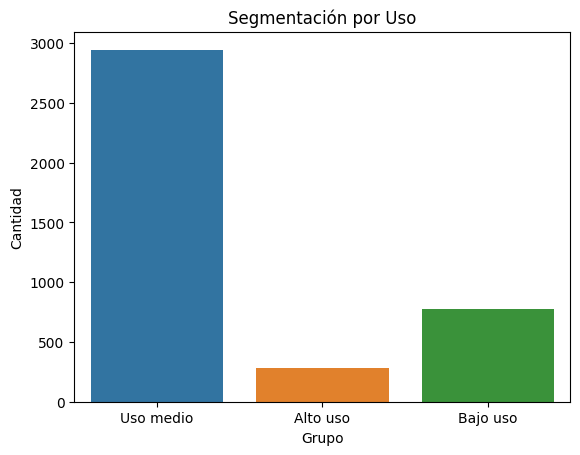

In [ ]:
# Visualización de los segmentos por uso

sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Segmentación por Uso')
plt.xlabel('Grupo')
plt.ylabel('Cantidad')
plt.show()

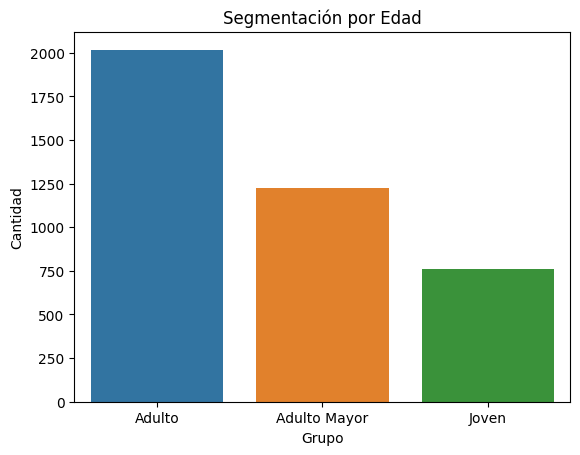

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Segmentación por Edad')
plt.xlabel('Grupo')
plt.ylabel('Cantidad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
1. ¿Qué problemas tenían originalmente los datos? ¿Qué porcentaje o cantidad de filas representaban?

Se identificaron varios problemas de calidad de datos:

Valores nulos en city: 469 registros (11.73% de los usuarios).
Valores nulos en churn_date: 3,534 registros (88.35%), aunque en este caso los nulos son esperados porque indican clientes activos.
Valores nulos en date: 50 registros (0.125% del dataset usage).
Valores nulos en duration (55.19%) y length (44.74%), que resultaron ser nulos estructurales asociados al tipo de registro (call o text).
Valores inválidos:
age = -999, utilizado como valor sentinel para datos faltantes.
city = "?", utilizado para representar información desconocida.
Fechas fuera de rango:
40 registros con año 2026 en reg_date, cuando el rango esperado era 2022-2024.

En general, la mayoría de los problemas pudieron explicarse y tratarse adecuadamente sin comprometer la calidad del análisis.

2. ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Se identificaron segmentos por:

Edad
Jóvenes
Adultos
Adultos Mayores

Los adultos representan el grupo más numeroso de clientes, seguidos por los jóvenes y posteriormente los adultos mayores.

Nivel de uso
Bajo uso
Uso medio
Alto uso

La mayoría de los usuarios se concentra en el segmento de uso medio, mientras que los usuarios de alto consumo constituyen un grupo más reducido pero importante para la empresa.

3. ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

Los usuarios de alto uso parecen ser los más valiosos para ConnectaTel porque:

Consumen más minutos y servicios.
Tienen mayor potencial de generar ingresos.
Son candidatos naturales para planes premium o paquetes especializados.
Permiten identificar oportunidades de venta cruzada y programas de fidelización.

También los usuarios adultos representan un segmento estratégico debido a su alta participación dentro de la base total de clientes.

4. ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Se identificaron outliers en:

Cantidad de mensajes
Cantidad de llamadas
Minutos de llamada

Especialmente en minutos de llamada, donde algunos usuarios alcanzan más de 150 minutos mientras la mayoría se encuentra muy por debajo de ese nivel.

Estos valores no parecen errores de captura, sino usuarios con patrones de consumo intensivo.

Implicaciones para el negocio:

Existen clientes con necesidades significativamente mayores que el promedio.
Los planes actuales podrían no estar optimizados para estos usuarios.
Representan una oportunidad para diseñar productos específicos para clientes de alto consumo.
5. ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes?
Crear un plan para usuarios de alto consumo
Más minutos incluidos.
Beneficios adicionales para llamadas frecuentes.
Incentivos de permanencia.
Desarrollar ofertas específicas por edad
Planes digitales y flexibles para usuarios jóvenes.
Planes con beneficios familiares para adultos.
Planes simples y fáciles de gestionar para adultos mayores.
Implementar estrategias de migración
Identificar usuarios de alto uso en planes Básicos y ofrecerles migrar a Premium.
Monitorear continuamente los patrones de consumo
Actualizar los segmentos periódicamente para adaptar la oferta a los cambios de comportamiento.
Mejorar la calidad de los datos
Evitar valores sentinel como -999 o "?".
Implementar validaciones de fechas para prevenir registros fuera de rango.
Establecer reglas de captura más estrictas para reducir datos faltantes.
Conclusión General

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo


⚠️ Problemas detectados en los datos

Se encontraron valores nulos en city (11.73%), churn_date (88.35%) y date (0.125%), además de nulos estructurales en duration y length asociados al tipo de registro.
Se identificaron valores inválidos (age = -999, city = "?") y 40 registros con fechas fuera de rango (año 2026 en reg_date).

🔍 Segmentos por Edad

Los Adultos representan el grupo más numeroso de clientes.
Los Jóvenes y Adultos Mayores también tienen una presencia importante, aunque en menor proporción.

📊 Segmentos por Nivel de Uso

La mayoría de los clientes pertenece al segmento de Uso medio, mostrando un consumo moderado de servicios.
Existe un grupo más pequeño de Alto uso, caracterizado por una mayor cantidad de llamadas, mensajes y minutos consumidos.

➡️ Esto sugiere que la base de clientes de ConnectaTel está compuesta principalmente por usuarios con patrones de consumo moderados, pero también existe un segmento de usuarios intensivos que podría beneficiarse de planes especializados y generar mayores ingresos para la empresa.

💡 Recomendaciones

Crear o fortalecer planes dirigidos a usuarios de alto consumo, incluyendo más minutos y beneficios adicionales para incentivar su permanencia.
Mejorar los procesos de captura y validación de datos para evitar valores inválidos, fechas fuera de rango y registros incompletos en futuras bases de datos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/ArelySoto/connectatel-analysis/tree/main